In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score,KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import joblib
from xgboost import XGBClassifier

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("dataset/dataset.csv")
df.head()


,name,student_id,age,gender,attendance,scholarship,co_curricular_activities,marks,assignment_submission,debtor,displaced,income,prediction
0,Aarav,S001,11,Male,95,Yes,Yes,88,Yes,No,No,180000,Low
1,Ananya,S002,12,Female,92,Yes,Yes,91,Yes,No,No,160000,Low
2,Rahul,S003,13,Male,68,No,No,45,Half,Yes,Yes,70000,High
3,Priya,S004,10,Female,85,Yes,Yes,78,Yes,No,No,140000,Low
4,Mohit,S005,14,Male,74,No,No,55,Half,Yes,No,90000,Medium


In [5]:
df.shape

(1186, 13)

In [6]:
df = df.drop(['name','student_id'],axis='columns')

In [7]:
df

,age,gender,attendance,scholarship,co_curricular_activities,marks,assignment_submission,debtor,displaced,income,prediction
0,11,Male,95,Yes,Yes,88,Yes,No,No,180000,Low
1,12,Female,92,Yes,Yes,91,Yes,No,No,160000,Low
2,13,Male,68,No,No,45,Half,Yes,Yes,70000,High
3,10,Female,85,Yes,Yes,78,Yes,No,No,140000,Low
4,14,Male,74,No,No,55,Half,Yes,No,90000,Medium
...,...,...,...,...,...,...,...,...,...,...,...
1181,14,Female,90,Yes,No,91,Yes,No,No,184219,Low
1182,15,Male,78,No,Yes,65,Half,Yes,No,108423,Medium
1183,10,Male,81,Yes,No,96,Yes,No,No,149957,Low
1184,11,Male,73,No,No,62,Half,Yes,No,118984,Medium


# EDA

In [8]:
marks_avg=df["marks"].mean()
marks_avg

np.float64(64.33642495784149)

In [9]:
income_avg=df["income"].mean()
income_avg

np.float64(127311.90472175379)

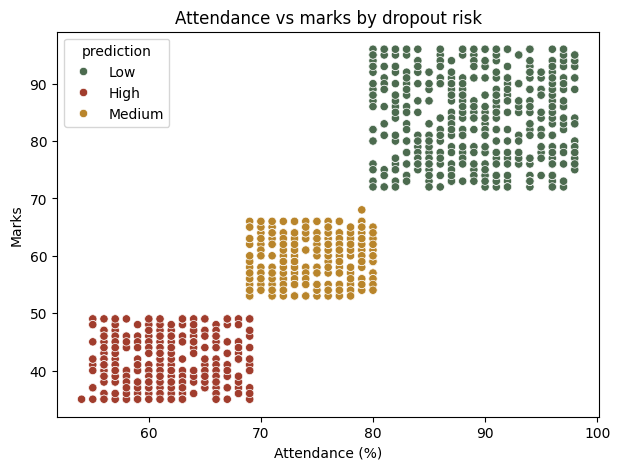

In [10]:

# fix the dirty label before plotting
df.loc[df["prediction"] == "LowA", "prediction"] = "Low"


# scatter: attendance vs marks, colored by dropout risk
plt.figure(figsize=(7,5))
sn.scatterplot(
    data=df, x="attendance", y="marks", hue="prediction",
    palette={"Low": "#4C6B4F", "Medium": "#B9852B", "High": "#A13D2D"}
)
plt.title("Attendance vs marks by dropout risk")
plt.xlabel("Attendance (%)")
plt.ylabel("Marks")
plt.show()

In [11]:
le=LabelEncoder()

In [12]:
df["prediction"]=le.fit_transform(df[["prediction"]])

/home/yash-rama/EarlyDrop-AI/lenv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [13]:
label_encoders = {}

In [14]:
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [15]:
joblib.dump(label_encoders,"label_encoding.joblib")

['label_encoding.joblib']

In [16]:
X=df.drop(["prediction"],axis="columns")
y=df.prediction

In [17]:
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2 , random_state=42)
X_train.head()

,age,gender,attendance,scholarship,co_curricular_activities,marks,assignment_submission,debtor,displaced,income
298,11,0,98,1,1,91,2,0,0,181318
711,11,1,83,1,1,78,2,0,0,161093
654,13,0,57,0,0,49,0,1,1,66821
275,10,1,58,0,0,46,0,1,1,69632
599,14,1,96,1,0,81,2,0,0,225564


In [18]:
X_test.head()

,age,gender,attendance,scholarship,co_curricular_activities,marks,assignment_submission,debtor,displaced,income
319,10,0,66,0,0,41,1,1,1,76856
956,10,0,78,0,1,65,0,1,0,118840
1182,15,1,78,0,1,65,0,1,0,108423
86,13,0,94,1,1,76,2,0,0,153301
990,15,0,69,0,0,42,1,1,1,74399


In [19]:
y_train.head()

298    1
711    1
654    0
275    0
599    1
Name: prediction, dtype: int64

In [20]:
y_test.head()

319     0
956     2
1182    2
86      1
990     0
Name: prediction, dtype: int64

In [21]:
scaler = MinMaxScaler()

In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
X_train_scaled[0:5]

array([[0.2       , 0.        , 1.        , 1.        , 1.        ,
        0.91803279, 1.        , 0.        , 0.        , 0.70190315],
       [0.2       , 1.        , 0.65116279, 1.        , 1.        ,
        0.70491803, 1.        , 0.        , 0.        , 0.58952018],
       [0.6       , 0.        , 0.04651163, 0.        , 0.        ,
        0.2295082 , 0.        , 1.        , 1.        , 0.06568499],
       [0.        , 1.        , 0.06976744, 0.        , 0.        ,
        0.18032787, 0.        , 1.        , 1.        , 0.0813047 ],
       [0.8       , 1.        , 0.95348837, 1.        , 0.        ,
        0.75409836, 1.        , 0.        , 0.        , 0.94776206]])

In [24]:
X_test_scaled[0:5]

array([[0.        , 0.        , 0.25581395, 0.        , 0.        ,
        0.09836066, 0.5       , 1.        , 1.        , 0.12144584],
       [0.        , 0.        , 0.53488372, 0.        , 1.        ,
        0.49180328, 0.        , 1.        , 0.        , 0.35473564],
       [1.        , 1.        , 0.53488372, 0.        , 1.        ,
        0.49180328, 0.        , 1.        , 0.        , 0.29685217],
       [0.6       , 0.        , 0.90697674, 1.        , 1.        ,
        0.67213115, 1.        , 0.        , 0.        , 0.54622288],
       [1.        , 0.        , 0.3255814 , 0.        , 0.        ,
        0.1147541 , 0.5       , 1.        , 1.        , 0.10779318]])

In [25]:
joblib.dump(scaler , "scaler.joblib")

['scaler.joblib']

In [26]:
k=KFold(n_splits=5)

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    "SVC": SVC(kernel="rbf", gamma='auto', random_state=42),
    "XgBoost": XGBClassifier(n_estimators=300, max_depth=8, random_state=42)
}

In [28]:
scores = {}


In [29]:
for name , model in models.items():
    cross_val_scores = cross_val_score(model, X_train_scaled, y_train, cv=k)    
    scores[name] = cross_val_scores
    print(f"{name} cross-validation scores: {cross_val_scores.mean()}")
    print("_"*50)

Logistic Regression cross-validation scores: 0.9989473684210527
__________________________________________________
Random Forest cross-validation scores: 1.0
__________________________________________________
SVC cross-validation scores: 0.9989473684210527
__________________________________________________
XgBoost cross-validation scores: 1.0
__________________________________________________


In [30]:
model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

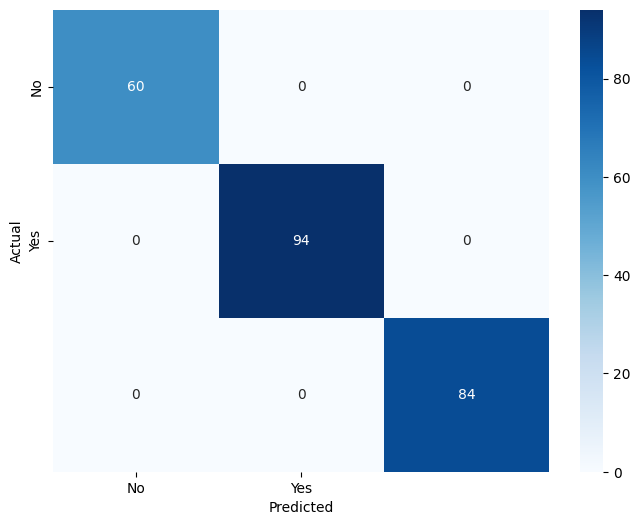

In [31]:
cm = confusion_matrix(y_test, models["Random Forest"].fit(X_train_scaled, y_train).predict(X_test_scaled))
plt.figure(figsize=(8,6))
sn.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Pandas Profiling Report")
profile

ModuleNotFoundError: No module named 'pkg_resources'

In [33]:
joblib.dump(model , "trained_model.joblib")

['trained_model.joblib']